### Flights Scraper Sky API

In [1]:
import sys
import os

# Check Python version
print(f"Python Version: `{sys.version}`")  # Detailed version info
print(f"Base Python location: `{sys.base_prefix}`")
print(f"Current Environment location: `{os.path.basename(sys.prefix)}`", end='\n\n')

Python Version: `3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]`
Base Python location: `C:\Users\LMT\AppData\Local\Programs\Python\Python312`
Current Environment location: `.venv`



In [2]:
import os
import sys
import pandas as pd
import json
from datetime import datetime, timedelta
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
if '../src' not in sys.path:
    sys.path.append('../src')
    
from flights_scraper_sky import FlightsScraperSky

# Load environment variables
load_dotenv()

# # Set display options
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', 100)
# pd.set_option('display.width', None)

True

In [4]:
# Get API key from environment
api_key = os.getenv('FLIGHTS_API_KEY')
# Initialize scanner
scanner = FlightsScraperSky(api_key)

In [6]:
london_results = scanner.search_airport("London")
data = london_results.get('data', [])

for idx, result in enumerate(data[:5], 1):
    presentation = result.get('presentation', {})
    print(f"{idx}. {presentation.get('title')} ({presentation.get('id')})")

https://flights-sky.p.rapidapi.com/flights/auto-complete | Searching airports with query: London
1. London (eyJlIjoiMjc1NDQwMDgiLCJzIjoiTE9ORCIsImgiOiIyNzU0NDAwOCIsInQiOiJDSVRZIn0=)
2. London Heathrow (eyJlIjoiOTU1NjUwNTAiLCJzIjoiTEhSIiwiaCI6IjI3NTQ0MDA4IiwidCI6IkFJUlBPUlQifQ==)
3. London Gatwick (eyJlIjoiOTU1NjUwNTEiLCJzIjoiTEdXIiwiaCI6IjI3NTQ0MDA4IiwidCI6IkFJUlBPUlQifQ==)
4. London Stansted (eyJlIjoiOTU1NjUwNTIiLCJzIjoiU1ROIiwiaCI6IjI3NTQ0MDA4IiwidCI6IkFJUlBPUlQifQ==)
5. London Luton (eyJlIjoiOTU1NjUwNTMiLCJzIjoiTFROIiwiaCI6IjI3NTQ0MDA4IiwidCI6IkFJUlBPUlQifQ==)


In [7]:
hcmc_results = scanner.search_airport("Ho Chi Minh")
data = hcmc_results.get('data', [])

for idx, result in enumerate(data[:5], 1):
    presentation = result.get('presentation', {})
    print(f"{idx}. {presentation.get('title')} ({presentation.get('id')})")

https://flights-sky.p.rapidapi.com/flights/auto-complete | Searching airports with query: Ho Chi Minh
1. Ho Chi Minh City (eyJlIjoiOTU2NzMzNzkiLCJzIjoiU0dOIiwiaCI6IjI3NTQ2MzI5IiwidCI6IkFJUlBPUlQifQ==)


In [8]:
origin_city = "London"
destination_city = "Ho Chi Minh"

london = scanner.get_location_ids(origin_city)
hcmc = scanner.get_location_ids(destination_city)

london, hcmc

https://flights-sky.p.rapidapi.com/flights/auto-complete | Searching airports with query: London
https://flights-sky.p.rapidapi.com/flights/auto-complete | Searching airports with query: Ho Chi Minh


({'entityId': 'eyJlIjoiMjc1NDQwMDgiLCJzIjoiTE9ORCIsImgiOiIyNzU0NDAwOCIsInQiOiJDSVRZIn0=',
  'skyId': 'LOND',
  'name': 'London'},
 {'entityId': 'eyJlIjoiOTU2NzMzNzkiLCJzIjoiU0dOIiwiaCI6IjI3NTQ2MzI5IiwidCI6IkFJUlBPUlQifQ==',
  'skyId': 'SGN',
  'name': 'Ho Chi Minh City'})

In [14]:
depart_date = "2026-03-07"
return_date = "2026-03-08"

results = scanner.search_roundtrip(
    from_entity_id=london['entityId'],
    to_entity_id=hcmc['entityId'],
    depart_date=depart_date,
    return_date=return_date
)

# Check if results are incomplete
if scanner.check_if_incomplete(results):
    session_id = results.get('data', {}).get('context', {}).get('sessionId')
    results = scanner.poll_incomplete_results(session_id)
    
flights_df = scanner.parse_flights(results)
flights_df

https://flights-sky.p.rapidapi.com/flights/search-roundtrip | Searching roundtrip flights from eyJlIjoiMjc1NDQwMDgiLCJzIjoiTE9ORCIsImgiOiIyNzU0NDAwOCIsInQiOiJDSVRZIn0= to eyJlIjoiOTU2NzMzNzkiLCJzIjoiU0dOIiwiaCI6IjI3NTQ2MzI5IiwidCI6IkFJUlBPUlQifQ==

Searching: eyJlIjoiMjc1NDQwMDgiLCJzIjoiTE9ORCIsImgiOiIyNzU0NDAwOCIsInQiOiJDSVRZIn0= -> eyJlIjoiOTU2NzMzNzkiLCJzIjoiU0dOIiwiaCI6IjI3NTQ2MzI5IiwidCI6IkFJUlBPUlQifQ==
Dates: 2026-03-07 to 2026-03-08


AttributeError: 'NoneType' object has no attribute 'get'

In [ ]:
# Display statistics
print("FLIGHT STATISTICS")
print("="*60)

print(f"\nTotal flights found: {len(flights_df)}")
print(f"\nPrice Statistics (GBP):")
print(f"  Minimum:  £{flights_df['price_gbp'].min():.2f}")
print(f"  Maximum:  £{flights_df['price_gbp'].max():.2f}")
print(f"  Mean:     £{flights_df['price_gbp'].mean():.2f}")
print(f"  Median:   £{flights_df['price_gbp'].median():.2f}")
print(f"  Std Dev:  £{flights_df['price_gbp'].std():.2f}")

print(f"\nStops Distribution:")
display(flights_df['total_stops'].value_counts().sort_index())

print(f"\nTop 5 Airlines by Number of Flights:")
display(flights_df['out_airline'].value_counts().head())


FLIGHT STATISTICS

Total flights found: 1076

Price Statistics (GBP):
  Minimum:  £858.48
  Maximum:  £2367.83
  Mean:     £1609.97
  Median:   £1627.92
  Std Dev:  £261.74

Stops Distribution:


total_stops
0      1
1     82
2    857
3    100
4     35
5      1
Name: count, dtype: int64


Top 5 Airlines by Number of Flights:


out_airline
Qatar Airways      311
Emirates           177
British Airways    148
China Southern      70
China Eastern       64
Name: count, dtype: int64

In [ ]:
print("TOP 10 CHEAPEST FLIGHTS")
print("="*60)

columns_to_show = [
    'price_gbp',
    'out_airline',
    'out_stops',
    'ret_stops',
    'total_stops',
    'out_duration_min',
    'ret_duration_min',
    'trip_length_days'
]

top_10 = flights_df.nsmallest(10, 'price_gbp')[columns_to_show]

# Format for better display
display_df = top_10.copy()
display_df['price_gbp'] = display_df['price_gbp'].apply(lambda x: f"£{x:.2f}")
display_df['out_duration'] = (top_10['out_duration_min'] / 60).apply(lambda x: f"{x:.1f}h")
display_df['ret_duration'] = (top_10['ret_duration_min'] / 60).apply(lambda x: f"{x:.1f}h")

display_df = display_df.drop(['out_duration_min', 'ret_duration_min'], axis=1)
display_df


TOP 10 CHEAPEST FLIGHTS


,price_gbp,out_airline,out_stops,ret_stops,total_stops,trip_length_days,out_duration,ret_duration
583,£858.48,"Ryanair, Wizz Air, Hainan Airlines",3,2,5,10,40.8h,25.9h
93,£948.00,Shenzhen Airlines,1,2,3,9,21.7h,32.9h
2,£982.00,Shenzhen Airlines,1,1,2,9,21.7h,19.8h
448,£988.00,China Eastern,1,2,3,9,25.2h,36.5h
134,£1005.00,Shenzhen Airlines,1,1,2,9,21.7h,31.6h
740,£1019.00,China Eastern,1,2,3,9,31.7h,32.9h
123,£1031.00,China Eastern,1,1,2,9,31.7h,19.8h
577,£1031.00,Qatar Airways,1,2,3,9,28.1h,32.9h
842,£1036.00,Qatar Airways,1,2,3,9,32.2h,32.9h
228,£1041.00,China Eastern,1,1,2,9,31.7h,22.3h


In [ ]:
print("CHEAPEST FLIGHT DETAILS")
print("="*60)

cheapest = flights_df.nsmallest(1, 'price_gbp').iloc[0]

print(f"\nPrice: £{cheapest['price_gbp']:.2f}")
print(f"Trip Length: {cheapest['trip_length_days']} days")
print(f"Total Stops: {cheapest['total_stops']}")

print(f"\n--- OUTBOUND FLIGHT ---")
print(f"Route: {cheapest['out_origin']} -> {cheapest['out_destination']}")
print(f"Departure: {cheapest['out_departure']}")
print(f"Arrival: {cheapest['out_arrival']}")
print(f"Duration: {cheapest['out_duration_min']} minutes ({cheapest['out_duration_min']/60:.1f} hours)")
print(f"Airline: {cheapest['out_airline']}")
print(f"Stops: {cheapest['out_stops']}")

if cheapest['out_stops'] > 0:
    print(f"Transit Airports: {cheapest['out_transit_airports']}")
    print(f"Layover Duration: {cheapest['out_layover_hours']} hours")
    print(f"Flight Numbers: {cheapest['out_flight_numbers']}")

print(f"\n--- RETURN FLIGHT ---")
print(f"Route: {cheapest['ret_origin']} -> {cheapest['ret_destination']}")
print(f"Departure: {cheapest['ret_departure']}")
print(f"Arrival: {cheapest['ret_arrival']}")
print(f"Duration: {cheapest['ret_duration_min']} minutes ({cheapest['ret_duration_min']/60:.1f} hours)")
print(f"Airline: {cheapest['ret_airline']}")
print(f"Stops: {cheapest['ret_stops']}")

if cheapest['ret_stops'] > 0:
    print(f"Transit Airports: {cheapest['ret_transit_airports']}")
    print(f"Layover Duration: {cheapest['ret_layover_hours']} hours")
    print(f"Flight Numbers: {cheapest['ret_flight_numbers']}")

CHEAPEST FLIGHT DETAILS

Price: £858.48
Trip Length: 10 days
Total Stops: 5

--- OUTBOUND FLIGHT ---
Route: STN -> SGN
Departure: 2025-12-20T08:05:00
Arrival: 2025-12-22T07:55:00
Duration: 2450 minutes (40.8 hours)
Airline: Ryanair, Wizz Air, Hainan Airlines
Stops: 3
Transit Airports: ['BUD', 'AUH', 'HAK']
Layover Duration: [1.6, 15.5, 6.2] hours
Flight Numbers: []

--- RETURN FLIGHT ---
Route: SGN -> LGW
Departure: 2025-12-30T12:00:00
Arrival: 2025-12-31T06:55:00
Duration: 1555 minutes (25.9 hours)
Airline: VietJet Air, Air China
Stops: 2
Transit Airports: ['HAN', 'PVG']
Layover Duration: [4.1, 4.2] hours
Flight Numbers: []


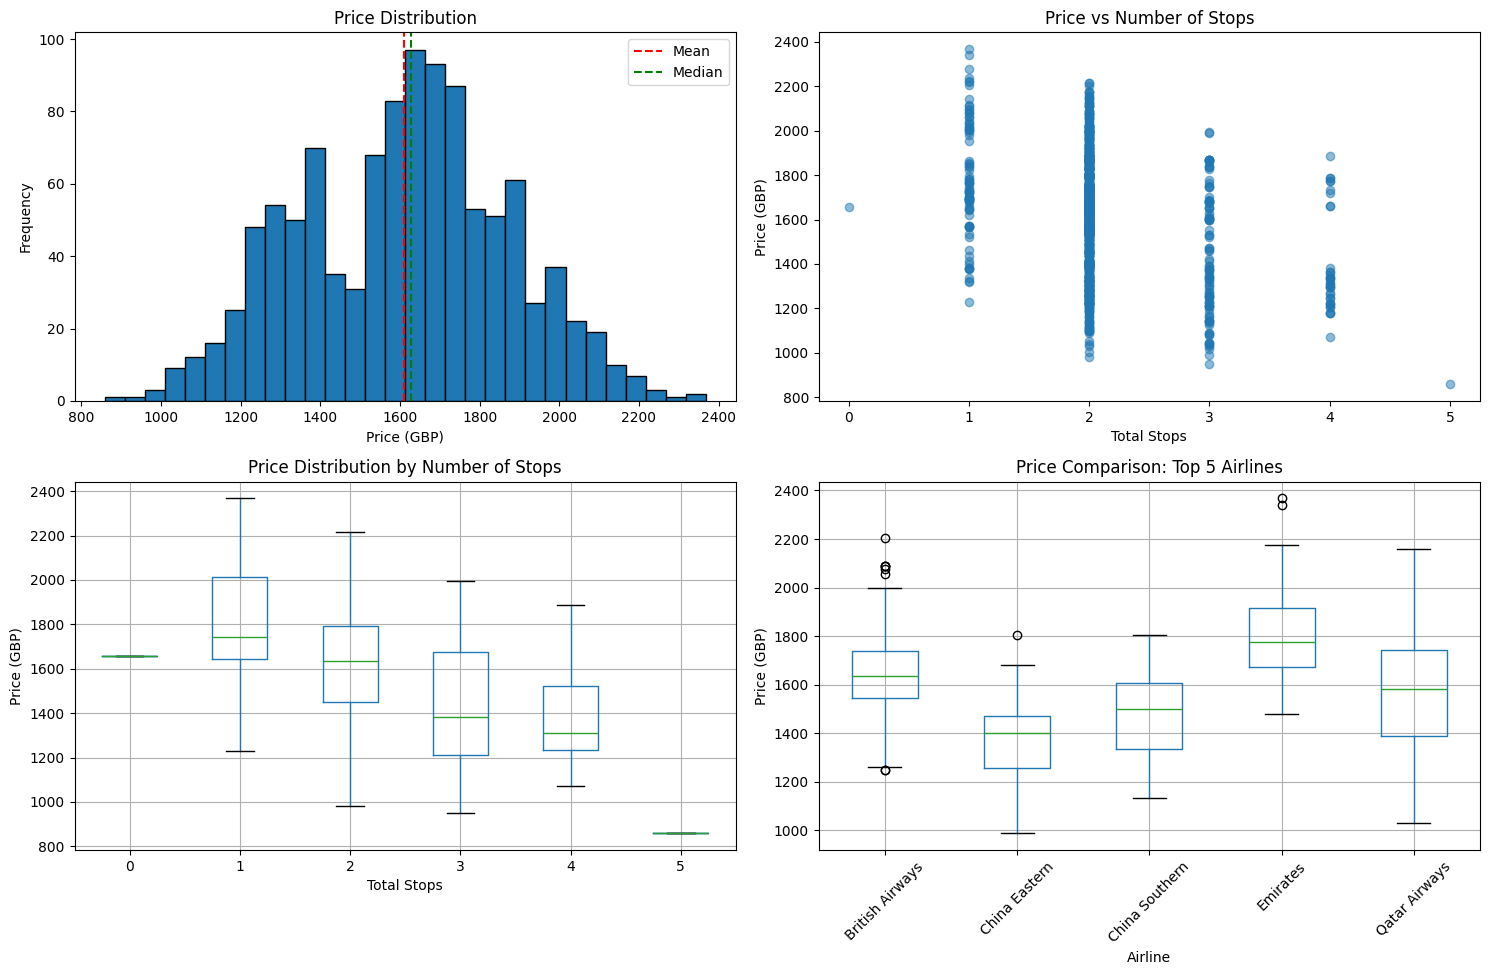

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Price histogram
axes[0, 0].hist(flights_df['price_gbp'], bins=30, edgecolor='black')
axes[0, 0].set_xlabel('Price (GBP)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].axvline(flights_df['price_gbp'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].axvline(flights_df['price_gbp'].median(), color='green', linestyle='--', label='Median')
axes[0, 0].legend()

# Price vs Stops
axes[0, 1].scatter(flights_df['total_stops'], flights_df['price_gbp'], alpha=0.5)
axes[0, 1].set_xlabel('Total Stops')
axes[0, 1].set_ylabel('Price (GBP)')
axes[0, 1].set_title('Price vs Number of Stops')

# Boxplot by stops
flights_df.boxplot(column='price_gbp', by='total_stops', ax=axes[1, 0])
axes[1, 0].set_xlabel('Total Stops')
axes[1, 0].set_ylabel('Price (GBP)')
axes[1, 0].set_title('Price Distribution by Number of Stops')
axes[1, 0].get_figure().suptitle('')

# Top airlines price comparison
top_airlines = flights_df['out_airline'].value_counts().head(5).index
filtered = flights_df[flights_df['out_airline'].isin(top_airlines)]
filtered.boxplot(column='price_gbp', by='out_airline', ax=axes[1, 1])
axes[1, 1].set_xlabel('Airline')
axes[1, 1].set_ylabel('Price (GBP)')
axes[1, 1].set_title('Price Comparison: Top 5 Airlines')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].get_figure().suptitle('')

plt.tight_layout()
plt.show()